In [1]:
%pip install yfinance matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --upgrade yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
print(sys.executable)

D:\Download\anaconda3\python.exe


In [4]:
import sys
!{sys.executable} -m pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


In [5]:
import yfinance as yf
print("yfinance installed successfully")

yfinance installed successfully


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:
data = yf.download('RELIANCE.NS', start = '2023-01-01', end = '2026-05-31')
data.info()

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 841 entries, 2023-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   841 non-null    float64
 1   (High, RELIANCE.NS)    841 non-null    float64
 2   (Low, RELIANCE.NS)     841 non-null    float64
 3   (Open, RELIANCE.NS)    841 non-null    float64
 4   (Volume, RELIANCE.NS)  841 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 39.4 KB


In [8]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1175.889648,1177.304802,1163.244669,1164.066352,5316175
2023-01-03,1167.284546,1174.565705,1163.062026,1170.936536,7658932
2023-01-04,1149.709595,1169.110728,1147.632506,1167.261851,9264891
2023-01-05,1147.655396,1157.858149,1143.067616,1151.969321,13637099
2023-01-06,1158.086182,1163.130505,1149.595379,1153.407118,6349597


In [9]:
data = data[['Close']].dropna()

data['Days'] = (data.index - data.index[0]).days

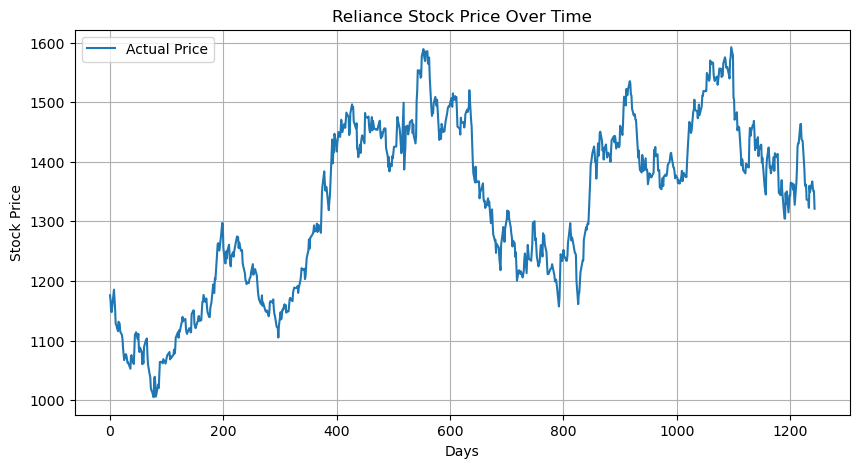

In [10]:
plt.figure(figsize = (10,5))
plt.plot(data['Days'], data['Close'], label = 'Actual Price')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Reliance Stock Price Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
X = data[['Days']]
y = data['Close']

model = LinearRegression()
model.fit(X , y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


D:\Download\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


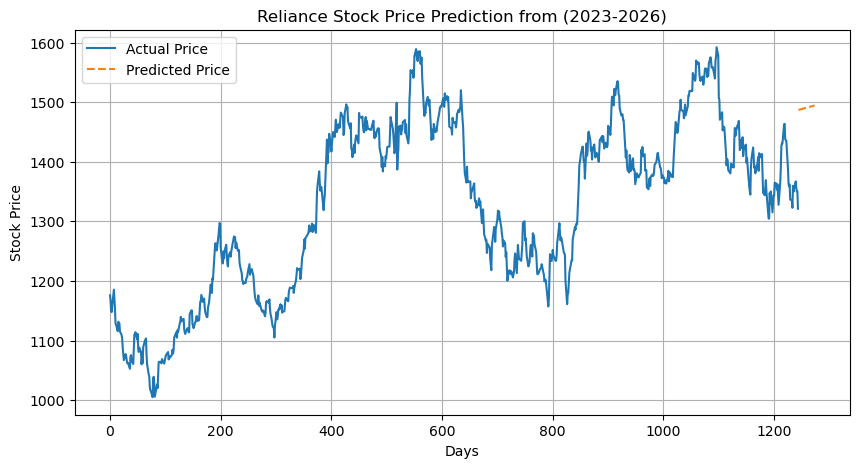

In [12]:
future_days = pd.DataFrame({'Days': range(data['Days'].max()+1, data['Days'].max()+31)})
future_prices = model.predict(future_days)

plt.figure(figsize=(10,5))
plt.plot(data['Days'], data['Close'], label= 'Actual Price')
plt.plot(future_days, future_prices, label= 'Predicted Price', linestyle='--')
plt.xlabel('Days')
plt.ylabel('Stock Price')
plt.title('Reliance Stock Price Prediction from (2023-2026)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
%pip install plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


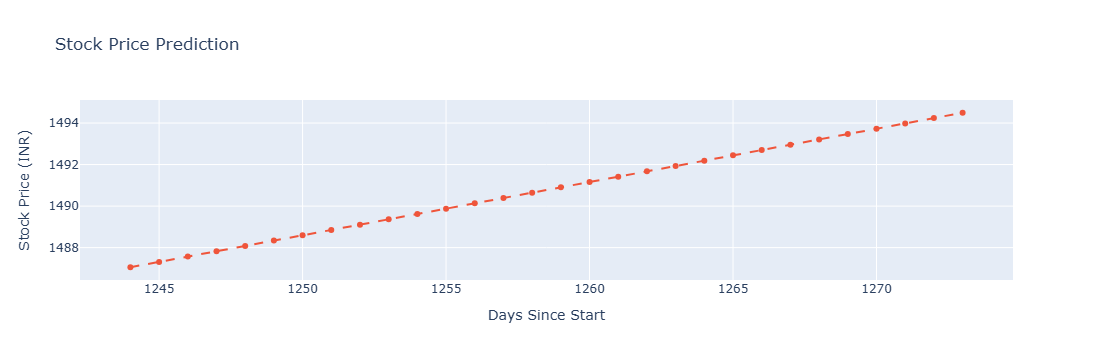

In [14]:
import plotly.graph_objs as go 
import plotly.offline as pyo

actual = data.copy()
actual['Type'] ='Actual'
future_days['Close'] = future_prices
future_days['Type'] = 'Predicted'

actual_plot = actual[['Days','Close','Type']].reset_index()
predicted_plot = future_days[['Days','Close','Type']]

combined = pd.concat([actual_plot,predicted_plot],ignore_index=True)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=combined[combined['Type'] == 'Actual']['Days'],
    y=combined[combined['Type'] == 'Actual']['Close'],
    mode='lines+markers',
    name='Actual Price',
    hoverinfo = 'text',
    text= combined[combined['Type'] == 'Actual'].apply(lambda row: f"Date: {row['Date'].strftime('%Y-%m-%d')}<br>Price: ₹{row['Close']:.2f}", axis=1)))

fig.add_trace(go.Scatter(
    x=combined[combined['Type'] == 'Predicted']['Days'],
    y=combined[combined['Type'] == 'Predicted']['Close'],
    mode='lines+markers',
    name='Predicted Price',
    line=dict(dash='dash'),
    hoverinfo = 'text',
    text =combined[combined['Type'] == 'Predicted'].apply(lambda row: f"Predicted Day: {row['Days']}<br>Price: ₹{row['Close']:.2f}", axis=1)))

fig.update_layout(
    title="Stock Price Prediction",
    xaxis_title = "Days Since Start",
    yaxis_title = "Stock Price (INR)",
    hovermode= "closest"
)

pyo.iplot(fig)
    
    
    

    

